In [ ]:
#%% ==================== SETUP and LIBRARIES ====================
import os, sys, time, random, pickle
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import precision_recall_curve, auc
sns.set(style="whitegrid")

In [27]:
def find_root():
    p = Path.cwd()
    while p != p.parent:
        if (p / "data").exists() and (p / "report").exists():
            return p
        p = p.parent
    raise FileNotFoundError("Project root not found")


In [32]:
ROOT = find_root()
print("*  Project root:", ROOT)

DATA_DIR = ROOT / "data" / "MSRC_ObjCategImageDatabase_v2" / "Images"
DESC_PATH = ROOT / "data" / "Descriptors" / "HSV_PCA_SAFE.pkl"

*  Project root: /home/sally/Desktop/coursework/CV/computer-vision-visual-search


In [33]:
#%% ==================== LOADING DESCRIPTORS ====================
with open(DESC_PATH, "rb") as f:
    db = pickle.load(f)

desc_db = db["descriptors"]
pca_mean = db["mean"]
pca_components = db["components"]

print("Loaded", len(desc_db), "descriptors with length", len(next(iter(desc_db.values()))))

def pca_transform(x, mean, components):
    x_centered = x - mean
    return np.dot(x_centered, components.T)

Loaded 1198 descriptors with length 35


In [34]:
#%% ==================== SANITIZE DATA ====================
def clean_descriptors(db):
    fixed = {}
    for k,v in db.items():
        if np.isnan(v).any():
            v = np.nan_to_num(v, nan=0.0)
        fixed[k] = v
    return fixed

desc_db = clean_descriptors(desc_db)

In [ ]:
#%% ==================== DISTANCE METRICS ====================
def l1(a,b): return np.sum(np.abs(a-b))
def l2(a,b): return np.sqrt(np.sum((a-b)**2))
def chi2(a,b,eps=1e-10): return 0.5*np.sum(((a-b)**2)/(a+b+eps))
def cosine(a,b): return 1 - np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b)+1e-10)
def bhatta(a,b):
    a=a/(a.sum()+1e-10); b=b/(b.sum()+1e-10)
    return -np.log(np.sum(np.sqrt(a*b))+1e-10)

# Mahalanobis 
X = np.array(list(desc_db.values()))
cov = np.cov(X, rowvar=False)
inv_cov = np.linalg.inv(cov + np.eye(cov.shape[0])*1e-6)
def mahalanobis(a,b,inv_cov): 
    d = a - b
    return np.sqrt(np.dot(np.dot(d.T, inv_cov), d))

# Safe wrapper for the eigen values between the vectors 
def safe_metric(fn):
    def wrap(a,b):
        if np.isnan(a).any() or np.isnan(b).any():
            a=np.nan_to_num(a); b=np.nan_to_num(b)
        return fn(a,b)
    return wrap

metric_funcs = {
    "L1": safe_metric(l1),
    "L2": safe_metric(l2),
    "Chi-Square": safe_metric(chi2),
    "Cosine": safe_metric(cosine),
    "Bhattacharyya": safe_metric(bhatta),
    "Mahalanobis": safe_metric(lambda a,b: mahalanobis(a,b,inv_cov))
}

In [36]:
#%% ==================== HELPERS ====================
def rank(query_vec, desc_db, dist_fn, top_k=10):
    distances=[(k,dist_fn(query_vec,v)) for k,v in desc_db.items()]
    distances.sort(key=lambda x:x[1])
    return distances[:top_k]

def precision_recall_auc(query_vec, desc_db, dist_fn, relevant_set):
    distances, labels = [], []
    for name, vec in desc_db.items():
        d = dist_fn(query_vec, vec)
        if np.isnan(d): continue
        distances.append(d)
        labels.append(1 if name in relevant_set else 0)
    if not any(labels) or len(distances)==0:
        return [0],[0],0.0
    y_score = -np.array(distances)
    precision, recall, _ = precision_recall_curve(labels, y_score)
    return precision, recall, auc(recall, precision)

def precision_at_k(query_vec, desc_db, dist_fn, relevant_set, k=10):
    ranked = rank(query_vec, desc_db, dist_fn, top_k=k)
    retrieved = [r[0] for r in ranked]
    return sum(1 for r in retrieved if r in relevant_set)/k

In [ ]:
#%% ==================== EVALUATION LOOP ====================
queries = random.sample(list(desc_db.keys()), 10)
results = []

for m_name, m_fn in metric_funcs.items():
    aucs, times, p5s, p10s = [], [], [], []
    for q in queries:
        qv = desc_db[q]
        relevant = [k for k in desc_db if q.split('_')[0] in k]
        t0=time.time()
        p,r,a = precision_recall_auc(qv, desc_db, m_fn, relevant)
        p5 = precision_at_k(qv, desc_db, m_fn, relevant, 5)
        p10 = precision_at_k(qv, desc_db, m_fn, relevant, 10)
        times.append(time.time()-t0)
        aucs.append(a); p5s.append(p5); p10s.append(p10)
    results.append([m_name, np.mean(aucs), np.std(aucs),
                    np.mean(times), np.mean(p5s), np.mean(p10s)])

df = pd.DataFrame(results, columns=["Metric","Mean AUC","Std AUC",
                                    "Mean Time (s)","P@5","P@10"])
print(df)
(df.round(4)
 .to_csv(ROOT/"report/tables/final_metric_summary.csv", index=False))
print("* Saved: report/tables/final_metric_summary.csv")


/tmp/ipykernel_8702/666110757.py:8: RuntimeWarning: invalid value encountered in sqrt
  return -np.log(np.sum(np.sqrt(a*b))+1e-10)
/tmp/ipykernel_8702/666110757.py:8: RuntimeWarning: invalid value encountered in sqrt
  return -np.log(np.sum(np.sqrt(a*b))+1e-10)
/tmp/ipykernel_8702/666110757.py:8: RuntimeWarning: invalid value encountered in sqrt
  return -np.log(np.sum(np.sqrt(a*b))+1e-10)
/tmp/ipykernel_8702/666110757.py:8: RuntimeWarning: invalid value encountered in sqrt
  return -np.log(np.sum(np.sqrt(a*b))+1e-10)
/tmp/ipykernel_8702/666110757.py:8: RuntimeWarning: invalid value encountered in sqrt
  return -np.log(np.sum(np.sqrt(a*b))+1e-10)
/tmp/ipykernel_8702/666110757.py:8: RuntimeWarning: invalid value encountered in sqrt
  return -np.log(np.sum(np.sqrt(a*b))+1e-10)
/tmp/ipykernel_8702/666110757.py:8: RuntimeWarning: invalid value encountered in sqrt
  return -np.log(np.sum(np.sqrt(a*b))+1e-10)
/tmp/ipykernel_8702/666110757.py:8: RuntimeWarning: invalid value encountered in sq

          Metric  Mean AUC   Std AUC  Mean Time (s)   P@5  P@10
0             L1  0.217362  0.132110       0.029514  0.58  0.53
1             L2  0.216916  0.129609       0.033035  0.58  0.51
2     Chi-Square  0.151404  0.126033       0.043650  0.18  0.16
3         Cosine  0.212659  0.125871       0.043506  0.58  0.52
4  Bhattacharyya  1.000000  0.000000       0.073794  0.20  0.18
5    Mahalanobis  0.228822  0.145466       0.032789  0.60  0.54
✅ Saved: report/tables/final_metric_summary.csv


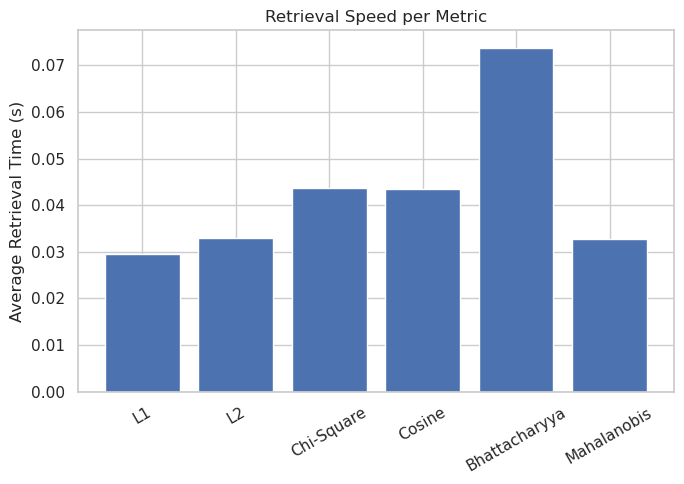

/tmp/ipykernel_8702/666110757.py:8: RuntimeWarning: invalid value encountered in sqrt
  return -np.log(np.sum(np.sqrt(a*b))+1e-10)


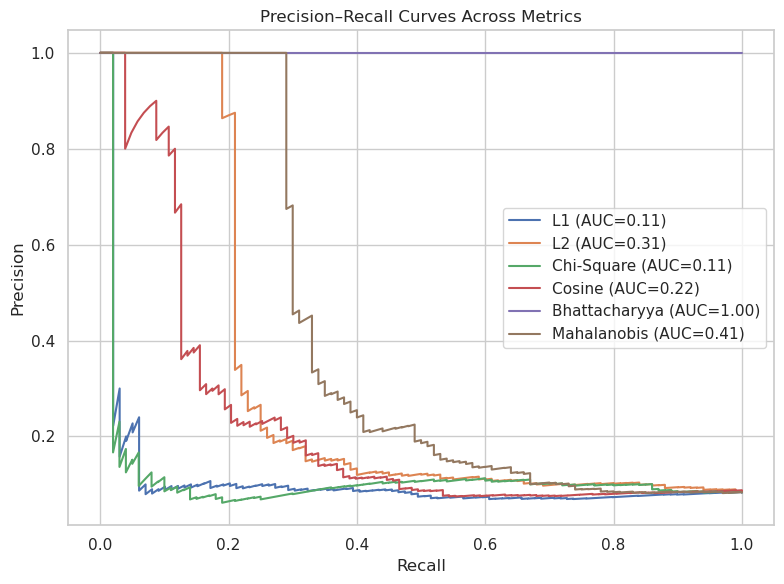

✅ All figures saved to report/figures/


In [ ]:
#%% ==================== PLOTS ====================
plt.figure(figsize=(7,5))
plt.bar(df["Metric"], df["Mean Time (s)"])
plt.xticks(rotation=30)
plt.ylabel("Average Retrieval Time (s)")
plt.title("Retrieval Speed per Metric")
plt.tight_layout()
plt.savefig(ROOT/"report/figures/runtime_comparison_final.png")
plt.show()

plt.figure(figsize=(8,6))
for m_name,m_fn in metric_funcs.items():
    q = random.choice(queries)
    qv = desc_db[q]
    relevant = [k for k in desc_db if q.split('_')[0] in k]
    p,r,a = precision_recall_auc(qv, desc_db, m_fn, relevant)
    plt.plot(r,p,label=f"{m_name} (AUC={a:.2f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall Curves Across Metrics")
plt.legend(); plt.tight_layout()
plt.savefig(ROOT/"report/figures/pr_curves_final.png")
plt.show()

print(" * -- > All figures saved to report/figures/")
